In [9]:
import pandas as pd
df = pd.read_csv(f"/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/AAFINAL_KMMFIT_4_msl.csv")
#df = df[~df["cluster"].isin([0, 5])].copy()
# Get sorted unique remaining clusters
#unique_clusters = sorted(df["cluster"].unique())

# Build mapping → start numbering from 1
#cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}

# Apply remapping
#df["cluster"] = df["cluster"].map(cluster_map)

In [11]:
import numpy as np
import pandas as pd

T = 10.0  # 100-year return period

def gev_return_level_scalar(mu, sigma, xi, T):
    """
    Scalar GEV return level for return period T.
    """
    p = 1.0 - 1.0 / T
    p = np.clip(p, 1e-12, 1 - 1e-12)

    if abs(xi) < 1e-10:
        return mu - sigma * np.log(-np.log(p))
    else:
        return mu + (sigma / xi) * ((-np.log(p))**(-xi) - 1.0)

# Compute station-level 100-year return level
df["RL10"] = [
    gev_return_level_scalar(mu, sig, xi, T)
    for mu, sig, xi in zip(df["gev_loc"], df["gev_scale"], df["gev_c"])
]

# Aggregate by cluster
cluster_RL10 = (
    df.groupby("cluster")["RL10"]
      .agg(["mean", "median", "std", "count"])
      .rename(columns={
          "mean": "RL10_mean",
          "median": "RL10_median",
          "std": "RL10_std",
          "count": "n_stations"
      })
      .reset_index()
)

print("\n10-year return level by cluster (station-level averaging):\n")
print(cluster_RL10.round(3))



10-year return level by cluster (station-level averaging):

   cluster  RL10_mean  RL10_median  RL10_std  n_stations
0        0      0.906        0.893     0.200         129
1        1      5.391        5.432     1.695          19
2        2      1.962        1.887     0.407          92
3        3      1.585        1.349     0.778          15


(<Figure size 800x600 with 1 Axes>,
 <GeoAxes: title={'center': 'GEV-based surge regimes'}>)

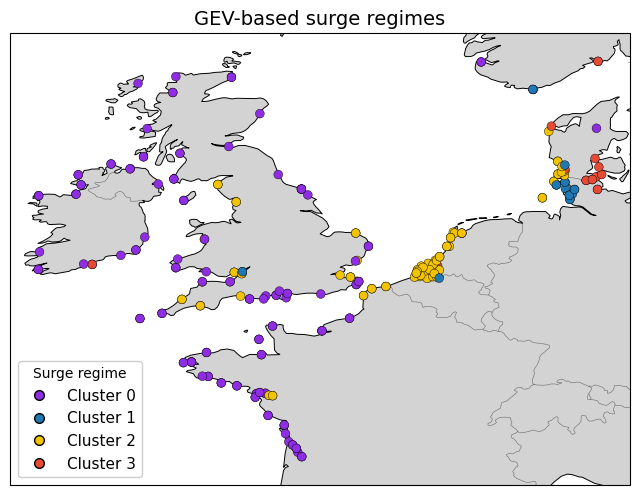

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_clusters_cartopy_discrete(
    df,
    lon_col="lon",
    lat_col="lat",
    cluster_col="cluster",
    figsize=(8, 6),
    title="GEV-based surge regimes",
    marker_size=30
):
    # Ensure clusters are integers and sorted
    clusters = np.sort(df[cluster_col].unique())
    n_clusters = len(clusters)

    base_colors = [
      "#8E2DE2",  # purple
     "#1F77B4",  # blue

         "#F2C300",  # yellow

    "#E64B35",  # orange-red (NEW)
 
       "#2CA02C",  # green
    ]
    colors = base_colors[:n_clusters]

    cmap = mcolors.ListedColormap(colors)
    bounds = np.arange(n_clusters + 1) - 0.5
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Map cluster labels to 0..K-1 for consistent coloring
    cluster_to_index = {c: i for i, c in enumerate(clusters)}
    color_index = df[cluster_col].map(cluster_to_index)

    # ---- Figure ----
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Base map
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)

    # Scatter plot (DISCRETE)
    sc = ax.scatter(
        df[lon_col],
        df[lat_col],
        c=color_index,
        cmap=cmap,
        norm=norm,
        s=marker_size,
        edgecolor="k",
        linewidth=0.3,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    # Map extent with padding
    pad = 1.0
    ax.set_extent(
        [
            df[lon_col].min() - pad,
            df[lon_col].max() + pad,
            df[lat_col].min() - pad,
            df[lat_col].max() + pad,
        ],
        crs=ccrs.PlateCarree(),
    )

    ax.set_title(title)

    # ---- Discrete legend (NOT a colorbar) ----
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=f"Cluster {c}",
            markerfacecolor=colors[i],
            markeredgecolor="k",
            markersize=7,
        )
        for i, c in enumerate(clusters)
    ]

    ax.legend(
        handles=handles,
        title="Surge regime",
        loc="lower left",
        frameon=True,
        framealpha=0.95
    )

    return fig, ax
plot_clusters_cartopy_discrete(
    df,
    lon_col="lon",
    lat_col="lat",
    cluster_col="cluster",
    figsize=(8, 6),
    title="GEV-based surge regimes",
    marker_size=40
)

In [21]:
 base_colors = [
      "#8E2DE2",  # purple
     "#1F77B4",  # blue

         "#F2C300",  # yellow

    "#E64B35",  # orange-red (NEW)
 
       "#2CA02C",  # green
    ]

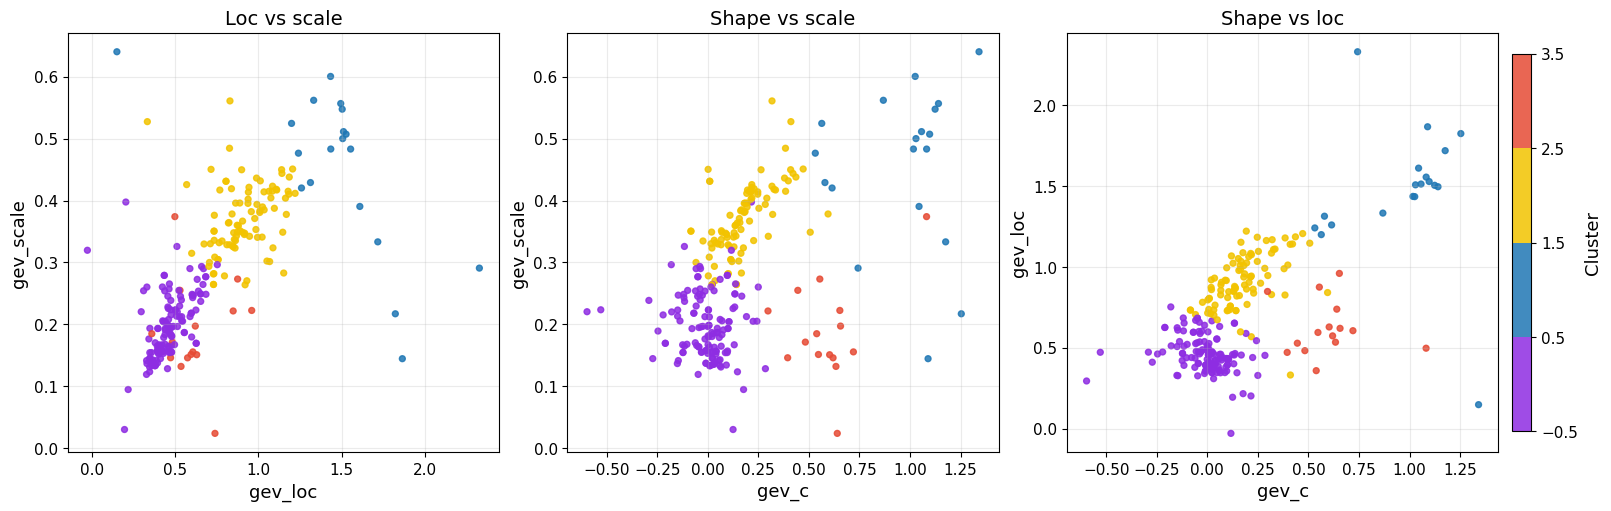

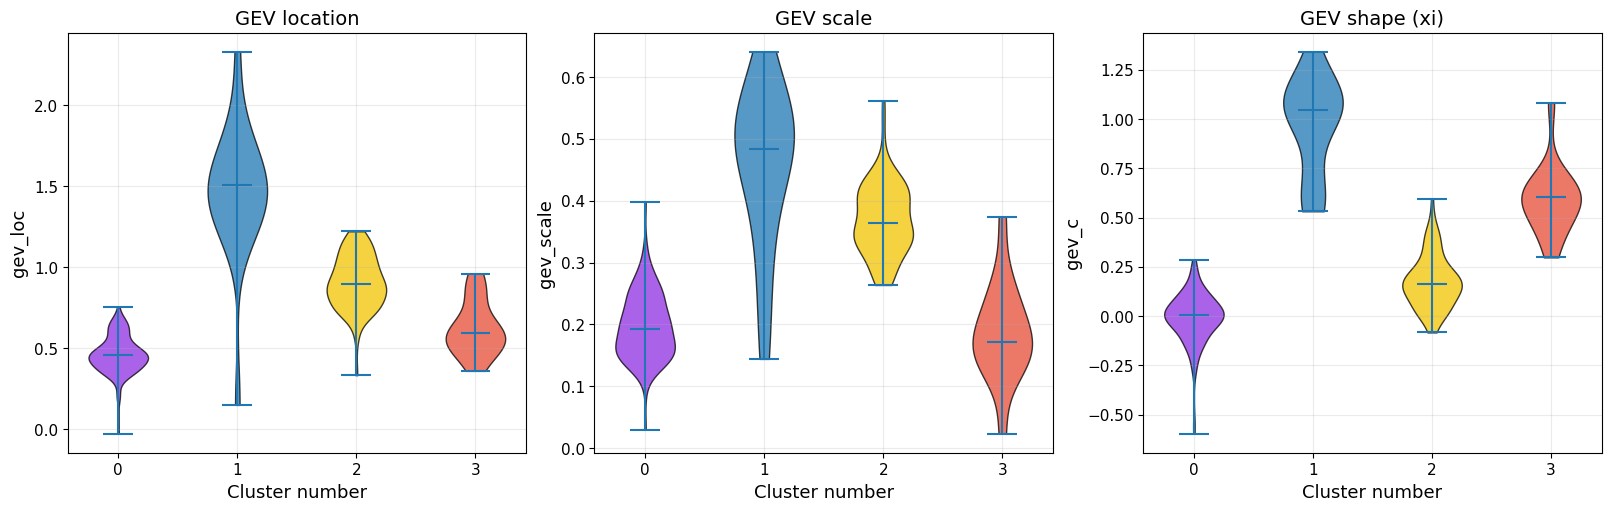

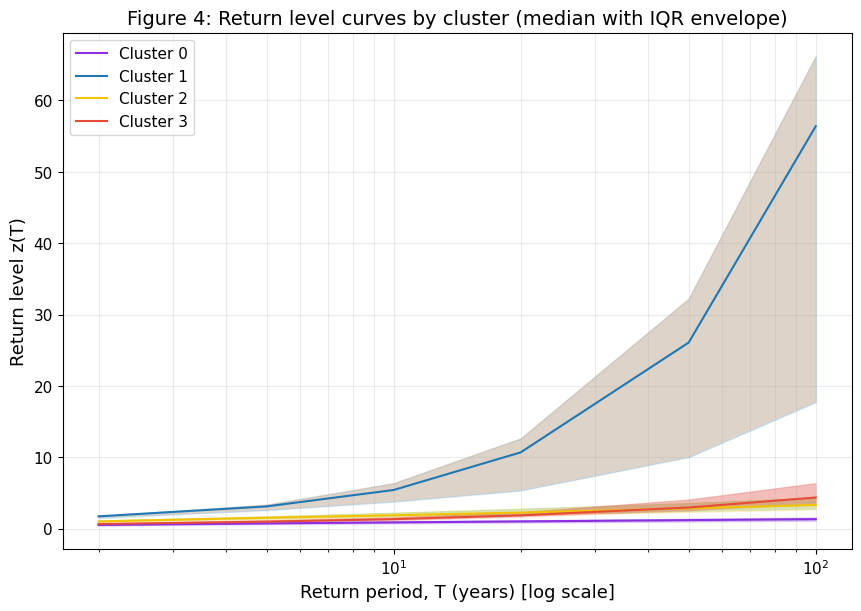

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_24224/2462108257.py:205: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_24224/2462108257.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, showfliers=False, patch_artist=True)
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_24224/2462108257.py:205: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_24224

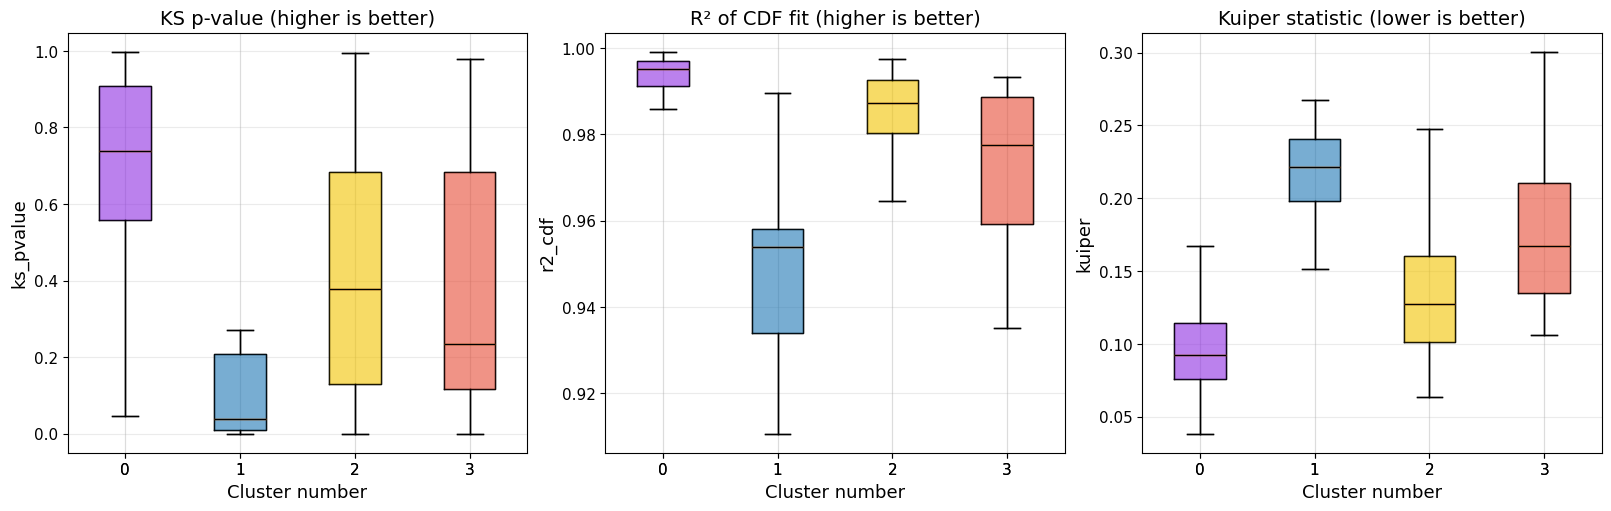

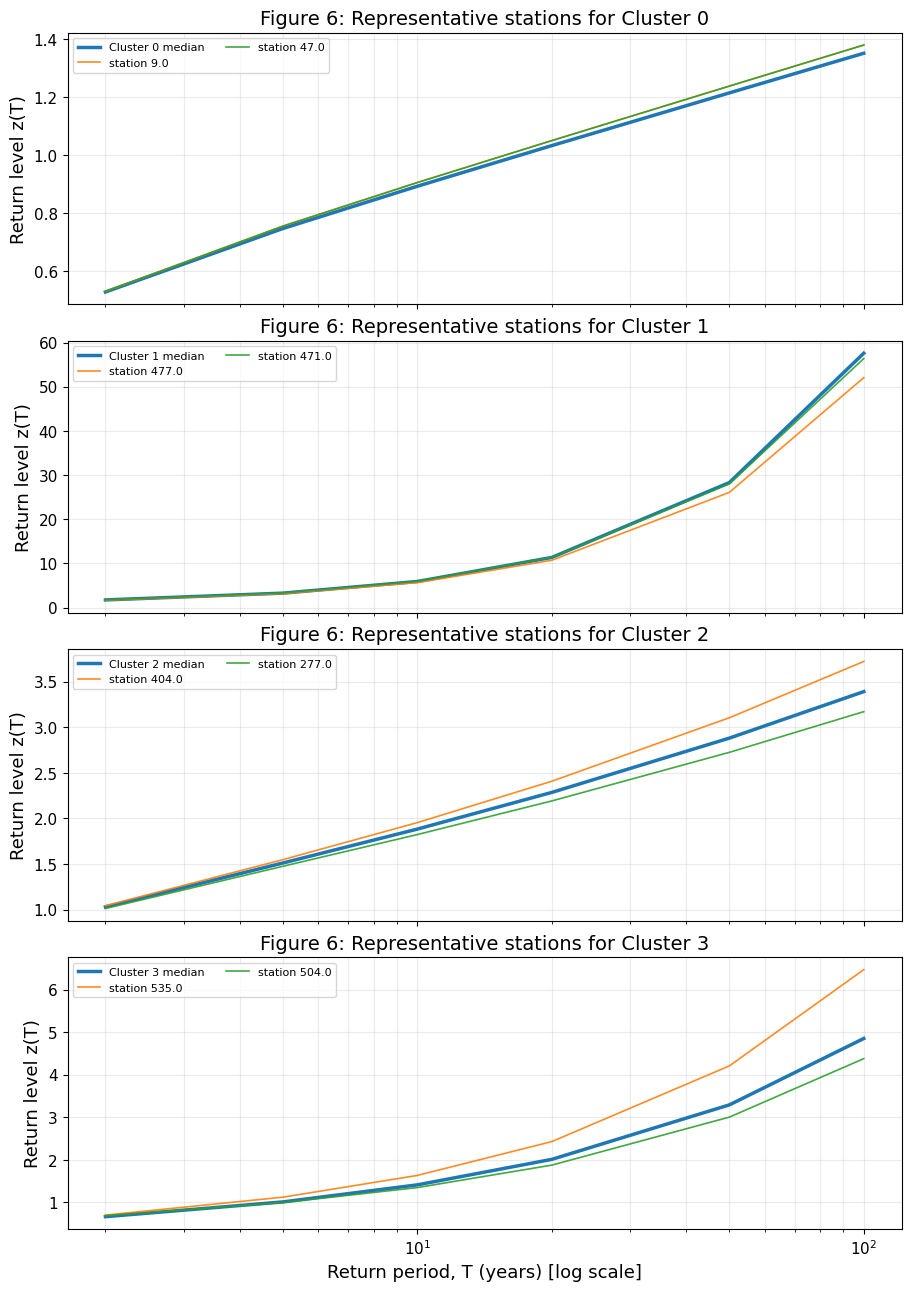

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.rcParams.update({
    "axes.titlesize": 14,   # subplot titles
    "axes.labelsize": 13,   # x/y labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16, # overall figure titles if used
})

def zscore(s):
    s = pd.Series(s)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-12)

def make_cluster_color_map(df, cluster_col="cluster", colors=base_colors):
    clusters = sorted(pd.Series(df[cluster_col]).astype(int).unique())
    if len(clusters) > len(colors):
        raise ValueError(f"Need {len(clusters)} colors but only have {len(colors)}.")
    cluster_to_color = {c: colors[i] for i, c in enumerate(clusters)}
    return clusters, cluster_to_color

def cluster_listed_cmap(clusters, cluster_to_color):
    return mcolors.ListedColormap([cluster_to_color[c] for c in clusters])

def gev_return_level(mu, sigma, xi, T):
    """
    Return level z_T for return period T (years) under GEV.
    p = 1 - 1/T (non-exceedance prob).
    """
    T = np.asarray(T, dtype=float)
    p = 1.0 - 1.0 / T
    # Avoid log(0)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    if np.isscalar(xi):
        if abs(xi) < 1e-10:
            return mu - sigma * np.log(-np.log(p))
        return mu + (sigma / xi) * ((-np.log(p))**(-xi) - 1.0)

    # vector xi
    xi = np.asarray(xi, dtype=float)
    out = np.empty((len(xi), len(T)), dtype=float)
    near0 = np.abs(xi) < 1e-10
    out[near0, :] = (mu[near0, None] - sigma[near0, None] * np.log(-np.log(p))[None, :])
    out[~near0, :] = (mu[~near0, None] + (sigma[~near0, None] / xi[~near0, None]) *
                      ((-np.log(p))[None, :]**(-xi[~near0, None]) - 1.0))
    return out

def ensure_cluster_int(df):
    df = df.copy()
    df["cluster"] = df["cluster"].astype(int)
    return df

def cluster_order_by(df, col="gev_c"):
    # order clusters by median of a column
    meds = df.groupby("cluster")[col].median().sort_values()
    return meds.index.to_list()

def get_cluster_order(df):
    return sorted(df["cluster"].astype(int).unique())

def pick_representative_sites(df, n_per_cluster=2, cols=("gev_c","gev_loc","gev_scale")):
    """
    Picks n_per_cluster stations closest to the cluster centroid
    in standardized (z-scored) parameter space.
    """
    tmp = df.copy()
    for c in cols:
        tmp[c + "_z"] = zscore(tmp[c])

    zcols = [c + "_z" for c in cols]
    reps = []
    for k, g in tmp.groupby("cluster"):
        centroid = g[zcols].mean().values
        X = g[zcols].values
        d = np.sqrt(((X - centroid)**2).sum(axis=1))
        idx = np.argsort(d)[:n_per_cluster]
        reps.append(g.iloc[idx])
    reps = pd.concat(reps, axis=0)
    return reps

# ----------------------------
# Figure 2: GEV parameter space (3 panels)
# ----------------------------
def fig2_parameter_space(df, savepath=None):
    df = ensure_cluster_int(df)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    pairs = [
        ("gev_loc", "gev_scale", "Loc vs scale"),
        ("gev_c", "gev_scale", "Shape vs scale"),
        ("gev_c", "gev_loc", "Shape vs loc"),
    ]
    for ax, (x, y, ttl) in zip(axes, pairs):
        clusters, cluster_to_color = make_cluster_color_map(df,  colors=base_colors)

        # map cluster -> 0..K-1 indices for consistent discrete coloring
        cluster_to_idx = {c: i for i, c in enumerate(clusters)}
        cidx = df["cluster"].map(cluster_to_idx)

        cmap = cluster_listed_cmap(clusters, cluster_to_color)
        norm = mcolors.BoundaryNorm(np.arange(len(clusters) + 1) - 0.5, cmap.N)

        sc = ax.scatter(df[x], df[y], c=cidx, cmap=cmap, norm=norm, s=18, alpha=0.85)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(ttl)
        ax.grid(True, alpha=0.25)

    cb = fig.colorbar(sc, ax=axes, shrink=0.9, pad=0.01)
    cb.set_label("Cluster")

    if savepath:
        fig.savefig(savepath, dpi=300)
    return fig, axes

# ----------------------------
# Figure 3: Parameter distributions by cluster (3 panels)
# ----------------------------
def fig3_param_distributions(df, savepath=None):
    df = ensure_cluster_int(df)
    order = get_cluster_order(df)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    params = [("gev_loc", "GEV location"), ("gev_scale", "GEV scale"), ("gev_c", "GEV shape (xi)")]
    for ax, (col, ttl) in zip(axes, params):
        data = [df.loc[df["cluster"] == k, col].dropna().values for k in order]
        vp = ax.violinplot(data, showmeans=False, showmedians=True, showextrema=True)
        
        clusters, cluster_to_color = make_cluster_color_map(df)
        order = get_cluster_order(df)

        # Color each violin body according to its cluster (in 'order')
        for body, k in zip(vp["bodies"], order):
            body.set_facecolor(cluster_to_color[int(k)])
            body.set_edgecolor("black")
            body.set_alpha(0.75)
            
        ax.set_title(ttl)
        ax.set_xlabel("Cluster number")
        ax.set_ylabel(col)
        ax.set_xticks(range(1, len(order) + 1))
        ax.set_xticklabels(order)
        ax.grid(True, alpha=0.25)
    return fig, axes
# ----------------------------
# Figure 4: Return level curves per cluster (median + IQR envelope)
# ----------------------------
def fig4_return_levels(df, Ts=(2, 5, 10, 20, 50, 100), savepath=None):
    df = ensure_cluster_int(df)
    Ts = np.asarray(Ts, dtype=float)

    fig, ax = plt.subplots(figsize=(8.5, 6), constrained_layout=True)

    for k, g in df.groupby("cluster"):
        mu = g["gev_loc"].values
        sigma = g["gev_scale"].values
        xi = g["gev_c"].values

        RL = gev_return_level(mu, sigma, xi, Ts)  # shape: (n_stations, n_T)
        # robust summaries across stations in cluster
        q25 = np.nanpercentile(RL, 25, axis=0)
        q50 = np.nanpercentile(RL, 50, axis=0)
        q75 = np.nanpercentile(RL, 75, axis=0)

       # ax.plot(Ts, q50, label=f"Cluster {k}")
        clusters, cluster_to_color = make_cluster_color_map(df)
        ax.plot(Ts, q50, color=cluster_to_color[k], label=f"Cluster {k}")
        ax.fill_between(Ts, q25, q75, color=cluster_to_color[k], alpha=0.18)
        ax.fill_between(Ts, q25, q75, alpha=0.18)

    ax.set_xscale("log")
    ax.set_xlabel("Return period, T (years) [log scale]")
    ax.set_ylabel("Return level z(T)")
    ax.set_title("Figure 4: Return level curves by cluster (median with IQR envelope)")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()

    if savepath:
        fig.savefig(savepath, dpi=300)
    return fig, ax

# ----------------------------
# Figure 5: Model adequacy by cluster (KS p-value, R2, Kuiper)
# ----------------------------
def fig5_fit_adequacy(df, savepath=None):
    df = ensure_cluster_int(df)
    order = get_cluster_order(df)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    metrics = [
        ("ks_pvalue", "KS p-value (higher is better)"),
        ("r2_cdf", "R² of CDF fit (higher is better)"),
        ("kuiper", "Kuiper statistic (lower is better)"),
    ]

    for ax, (col, ttl) in zip(axes, metrics):
        data = [df.loc[df["cluster"] == k, col].dropna().values for k in order]
        ax.boxplot(data, labels=order, showfliers=False)
        bp = ax.boxplot(data, labels=order, showfliers=False, patch_artist=True)

        clusters, cluster_to_color = make_cluster_color_map(df)

        for patch, k in zip(bp["boxes"], order):
            patch.set_facecolor(cluster_to_color[int(k)])
            patch.set_alpha(0.6)
            patch.set_edgecolor("black")

        for element in ["whiskers", "caps", "medians"]:
            for line in bp[element]:
                line.set_color("black")
                ax.set_title(ttl)
                ax.set_xlabel("Cluster number")
                ax.set_ylabel(col)
                ax.grid(True, alpha=0.25)

    if savepath:
        fig.savefig(savepath, dpi=300)
    return fig, axes

# ----------------------------
# Figure 6: Representative sites per cluster
#   - pick 2 closest-to-centroid stations per cluster in z-scored GEV space
#   - show each representative station’s return level curve (thin),
#     plus cluster median (thick) for context
# ----------------------------
def fig6_representative_sites(df, n_per_cluster=2, Ts=(2, 5, 10, 20, 50, 100), savepath=None):
    df = ensure_cluster_int(df)
    Ts = np.asarray(Ts, dtype=float)

    reps = pick_representative_sites(df, n_per_cluster=n_per_cluster)
    clusters = sorted(df["cluster"].unique())

    nrows = len(clusters)
    fig, axes = plt.subplots(nrows, 1, figsize=(9, 3.2 * nrows), constrained_layout=True, sharex=True)

    if nrows == 1:
        axes = [axes]

    for ax, k in zip(axes, clusters):
        g = df[df["cluster"] == k]
        r = reps[reps["cluster"] == k]

        # cluster median curve
        mu_med = np.nanmedian(g["gev_loc"].values)
        sig_med = np.nanmedian(g["gev_scale"].values)
        xi_med = np.nanmedian(g["gev_c"].values)
        rl_med = gev_return_level(mu_med, sig_med, xi_med, Ts)
        ax.plot(Ts, rl_med, linewidth=2.5, label=f"Cluster {k} median")

        # representative station curves
        for _, row in r.iterrows():
            rl = gev_return_level(row["gev_loc"], row["gev_scale"], row["gev_c"], Ts)
            lab = f"station {row.get('station', row.name)}"
            ax.plot(Ts, rl, linewidth=1.2, alpha=0.9, label=lab)

        ax.set_xscale("log")
        ax.set_ylabel("Return level z(T)")
        ax.set_title(f"Figure 6: Representative stations for Cluster {k}")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(fontsize=8, ncol=2)

    axes[-1].set_xlabel("Return period, T (years) [log scale]")

    if savepath:
        fig.savefig(savepath, dpi=300)
    return fig, axes

# 2) Parameter space (3 panels)
fig2, ax2 = fig2_parameter_space(df)
plt.show()

# 3) Parameter distributions
fig3, ax3 = fig3_param_distributions(df)
plt.show()

# 4) Return level curves
fig4, ax4 = fig4_return_levels(df, Ts=[2, 5, 10, 20, 50, 100])
plt.show()

# 5) Fit adequacy by cluster
fig5, ax5 = fig5_fit_adequacy(df)
plt.show()

# 6) Representative stations per cluster
fig6, ax6 = fig6_representative_sites(df, n_per_cluster=2, Ts=[2, 5, 10, 20, 50, 100])
plt.show()

In [23]:
import seaborn as sns

# ensure cluster is int (consistent with your pipeline)
df_plot = ensure_cluster_int(df)

# use the same three GEV parameters
vars_to_plot = ["gev_loc", "gev_scale", "gev_c"]

# drop NaNs for clean plotting
df_plot = df_plot[vars_to_plot + ["cluster"]].dropna()

# get consistent cluster ordering + colors
clusters, cluster_to_color = make_cluster_color_map(df_plot)

# seaborn expects a palette list in order of hue levels
palette = [cluster_to_color[c] for c in clusters]

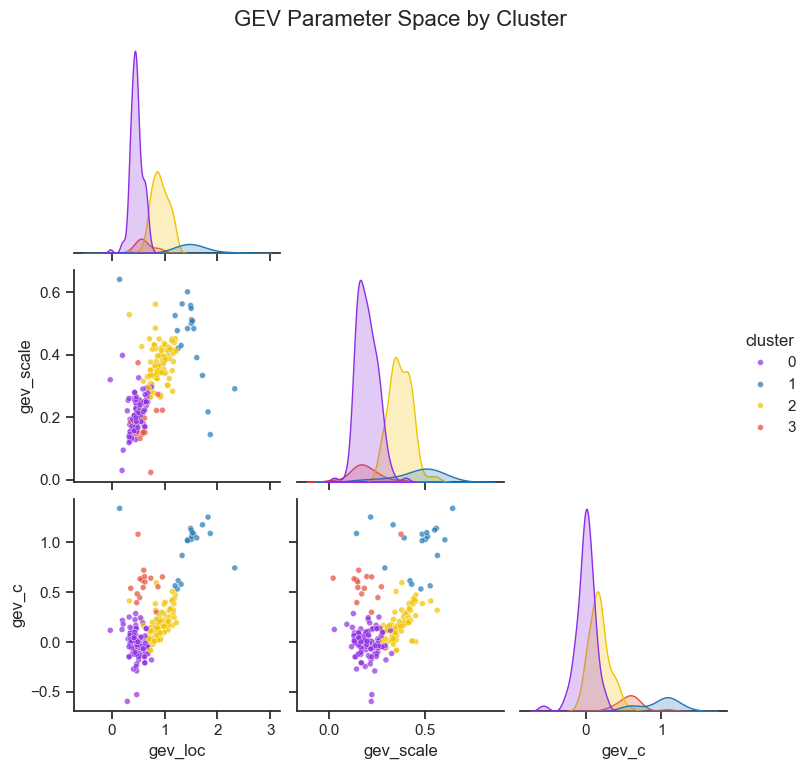

In [24]:
sns.set(style="ticks")

g = sns.pairplot(
    df_plot,
    vars=vars_to_plot,
    hue="cluster",
    hue_order=clusters,
    palette=palette,
    corner=True,        # cleaner layout
    diag_kind="kde",
    plot_kws={
        "s": 18,
        "alpha": 0.7
    }
)

g.fig.suptitle("GEV Parameter Space by Cluster", y=1.02)
plt.show()

In [25]:
vars_to_plot = ["gev_loc", "gev_scale", "gev_c"]

df_plot = ensure_cluster_int(df)

# normalize per variable (global normalization, not per cluster)
for col in vars_to_plot:
    df_plot[col + "_z"] = zscore(df_plot[col])

z_vars = [col + "_z" for col in vars_to_plot]

# keep only needed columns
df_plot = df_plot[z_vars + ["cluster"]].dropna()

In [27]:
df_long = df_plot.melt(
    id_vars="cluster",
    value_vars=z_vars,
    var_name="variable",
    value_name="value"
)
clusters, cluster_to_color = make_cluster_color_map(df_plot)

palette = {c: cluster_to_color[c] for c in clusters}